In [8]:
!pip install tshark
!pip install pyshark
!pip install pandas
!pip install gym
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
%pip install matplotlib
%pip install seaborn

ERROR: Could not find a version that satisfies the requirement tshark (from versions: none)
ERROR: No matching distribution found for tshark


Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import nest_asyncio
import pyshark
import socket
import json
import time
from datetime import datetime
import pandas as pd

nest_asyncio.apply()

# Graylog configurations
GRAYLOG_HOST = '192.168.1.3'  # Change this to your Graylog IP
GRAYLOG_PORT = 5140           # GELF TCP input port (must be open in Graylog)

def send_to_graylog(message_dict):
    """Send a single message to Graylog in GELF format."""
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.connect((GRAYLOG_HOST, GRAYLOG_PORT))

    gelf_message = {
        "version": "1.1",
        "host": "wireless-sniffer",
        "short_message": "802.11 Packet",
        "timestamp": time.mktime(message_dict['frame_time'].timetuple()),
        "_frame_len": message_dict['frame_len'],
        "_fc_subtype": message_dict['wlan_fc_subtype'],
        "_signal_strength": message_dict['signal_strength'],
        "_channel_freq": message_dict['channel_freq'],
        "_wlan_ta": message_dict['wlan_ta'],
        "_wlan_sa": message_dict['wlan_sa'],
        "_wlan_da": message_dict['wlan_da'],
        "_ssid": message_dict.get('ssid'),
        "_frame_type": message_dict.get('frame_type'),
        "_ta_is_broadcast": message_dict.get('ta_is_broadcast', 0)
    }

    sock.sendall((json.dumps(gelf_message) + '\0').encode('utf-8'))
    sock.close()

def extract_to_graylog(pcap_file, output_csv='wireless_features.csv'):
    """Extracts 802.11 packet features from pcap and sends to Graylog + returns dataframe."""
    capture = pyshark.FileCapture(pcap_file, display_filter="wlan", use_json=True)
    feature_list = []

    packet_count = 0
    for pkt in capture:
        packet_count += 1
        try:
            print(f"Processing packet {packet_count}")
            if 'WLAN' not in pkt:
                print(f"Skipping packet {packet_count}: No WLAN layer")
                continue

            wlan = pkt.wlan
            radio = pkt.radiotap if hasattr(pkt, 'radiotap') else None

            # Handle missing or nested subtype/type
            frame_type = getattr(wlan, 'type', None)
            frame_subtype = getattr(wlan, 'subtype', None)
            if frame_type is None or frame_subtype is None:
                if hasattr(wlan, 'fc_tree'):
                    fc = wlan.fc_tree
                    frame_type = getattr(fc, 'type', None)
                    frame_subtype = getattr(fc, 'subtype', None)

            # Extract SSID
            ssid = getattr(wlan, 'ssid', None)

            # Signal strength
            signal_strength = -100
            if radio and hasattr(radio, 'dbm_antsignal'):
                signal_strength = int(radio.dbm_antsignal[0]) if isinstance(radio.dbm_antsignal, list) else int(radio.dbm_antsignal)

            # Channel
            channel_freq = int(getattr(radio, 'channel_freq', 0)) if radio else 0

            # Build data record
            data = {
                'frame_time': pkt.sniff_time,
                'frame_len': int(pkt.length),
                'wlan_fc_subtype': frame_subtype,
                'wlan_ta': getattr(wlan, 'ta', None),
                'wlan_sa': getattr(wlan, 'sa', None),
                'wlan_da': getattr(wlan, 'da', None),
                'signal_strength': signal_strength,
                'channel_freq': channel_freq,
                'ssid': ssid,
                'frame_type': frame_type,
                'frame_subtype': frame_subtype
            }

            data['ta_is_broadcast'] = 1 if data['wlan_ta'] and data['wlan_ta'].startswith('ff:ff:ff') else 0

            print(f"Extracted features: {data}")

            send_to_graylog(data)
            feature_list.append(data)

        except AttributeError as e:
            print(f"Skipping packet {packet_count} due to error: {e}")
            continue

    capture.close()

    # Save and return DataFrame
    if feature_list:
        df = pd.DataFrame(feature_list)
        df.to_csv(output_csv, index=False)
        print(f"✅ Extracted and saved data to {output_csv}")
        print("\n📋 First 10 rows of extracted data:\n")
        print(df.head(10))
    else:
        print("No packets were extracted.")
        df = pd.DataFrame()

    return df

# Example usage
df = extract_to_graylog('C:\Users\jwajn\Desktop\Research Paper\Code\capture2.pcap', 'wireless_features.csv')

FileNotFoundError: [Errno 2] No such file or directory: \home\josh\wireless\project\capture2.pcap

Label distribution:
 label
normal    3919
probe      534
deauth     512
Name: count, dtype: int64

Classification Report:
               precision    recall  f1-score   support

      deauth       1.00      1.00      1.00       150
      normal       1.00      1.00      1.00      1172
       probe       1.00      1.00      1.00       168

    accuracy                           1.00      1490
   macro avg       1.00      1.00      1.00      1490
weighted avg       1.00      1.00      1.00      1490



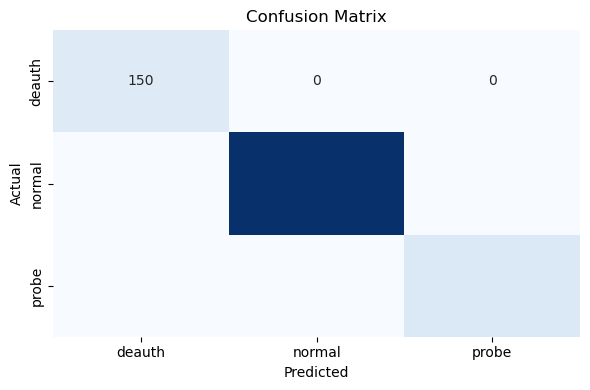

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Load the CSV (change path if needed)
df = pd.read_csv("C:/Users/jwajn/Desktop/Research Paper/Code/wireless_features.csv")

# Smart auto-labeling (for testing purposes)
def label_packet(row):
    if row['wlan_fc_subtype'] == 12 and row['signal_strength'] < -70:
        return 'deauth'
    elif row['wlan_fc_subtype'] == 4:
        return 'probe'
    else:
        return 'normal'

df['label'] = df.apply(label_packet, axis=1)

# Optional: Print class balance
print("Label distribution:\n", df['label'].value_counts())

# Encode SSID (if exists)
if 'ssid' in df.columns:
    df['ssid_encoded'] = df['ssid'].astype('category').cat.codes
else:
    df['ssid_encoded'] = 0  # fallback in case SSID missing

# Features and labels
features = df[['frame_len', 'wlan_fc_subtype', 'signal_strength', 'channel_freq',
               'frame_type', 'frame_subtype', 'ta_is_broadcast', 'ssid_encoded']]
labels = df['label']

# Drop NaNs
features = features.fillna(0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42)

# Train model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluation
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [9]:
import gym
import numpy as np
from gym.spaces import Discrete, Box

class WirelessEnv(gym.Env):
    """Custom Gym environment for wireless IDS."""
    def __init__(self, data):
        super(WirelessEnv, self).__init__()
        self.data = data
        self.current_step = 0

        self.observation_space = Box(low=-np.inf, high=np.inf, shape=(8,), dtype=np.float32)
        self.action_space = Discrete(2)  # 0: normal, 1: alert_intrusion

    def reset(self):
        self.current_step = 0
        return self._get_obs()

    def _get_obs(self):
        return self.data[self.current_step][:-1]  # exclude label

    def step(self, action):
        label = self.data[self.current_step][-1]  # actual label
        done = self.current_step >= len(self.data) - 1

        # Reward logic
        true_action = 0 if label == 'normal' else 1
        reward = 1 if action == true_action else -1

        self.current_step += 1
        obs = self._get_obs() if not done else np.zeros(8)

        return obs, reward, done, {}

    def render(self, mode='human'):
        pass


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np

class GPROAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99):
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.gamma = gamma
        self.memory = []

    def act(self, state, epsilon=0.1):
        if random.random() < epsilon:
            return random.randint(0, 1)
        state = torch.FloatTensor(state).unsqueeze(0)
        q_values = self.model(state)
        return q_values.argmax().item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self, batch_size=64):
        if len(self.memory) < batch_size:
            return

        minibatch = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*minibatch)

        states = torch.FloatTensor(states)
        next_states = torch.FloatTensor(next_states)
        actions = torch.LongTensor(actions)
        rewards = torch.FloatTensor(rewards)
        dones = torch.BoolTensor(dones)

        q_values = self.model(states)
        next_q_values = self.model(next_states)

        target_q = q_values.clone()
        for i in range(batch_size):
            target = rewards[i]
            if not dones[i]:
                target += self.gamma * next_q_values[i].max().item()
            target_q[i][actions[i]] = target

        loss = nn.MSELoss()(q_values, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


In [2]:
import gym
import numpy as np

class WirelessEnv(gym.Env):
    def __init__(self, data):
        super(WirelessEnv, self).__init__()
        self.data = data
        self.idx = 0
        self.state_dim = data.shape[1] - 1
        self.action_space = gym.spaces.Discrete(2)  # normal or intrusion
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_dim,), dtype=np.float32)

    def reset(self):
        self.idx = 0
        return self.data[self.idx, :-1]

    def step(self, action):
        label = self.data[self.idx, -1]
        reward = 1 if action == label else -1
        self.idx += 1
        done = self.idx >= len(self.data)
        next_state = self.data[self.idx, :-1] if not done else np.zeros_like(self.data[0, :-1])
        return next_state, reward, done, {}


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import numpy as np

class GPROAgent:
    def __init__(self, state_dim, action_dim, gamma=0.99, lr=1e-3, memory_size=10000, batch_size=64):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.lr = lr
        self.batch_size = batch_size
        self.memory = deque(maxlen=memory_size)

        self.model = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.criterion = nn.MSELoss()

    def act(self, state):
        if random.random() < 0.1:
            return random.randint(0, self.action_dim - 1)
        state = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.model(state)
        return q_values.argmax().item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(next_states)
        dones = torch.FloatTensor(dones).unsqueeze(1)

        q_values = self.model(states).gather(1, actions)
        next_q_values = self.model(next_states).max(1)[0].unsqueeze(1)
        target_q_values = rewards + self.gamma * next_q_values * (1 - dones)

        loss = self.criterion(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


Episode 1: Total Reward = -4405
Episode 2: Total Reward = 2067
Episode 3: Total Reward = -1887
Episode 4: Total Reward = -3601
Episode 5: Total Reward = 995
Episode 6: Total Reward = 3499
Episode 7: Total Reward = 4475
Episode 8: Total Reward = 4441
Episode 9: Total Reward = 4441
Episode 10: Total Reward = 4481


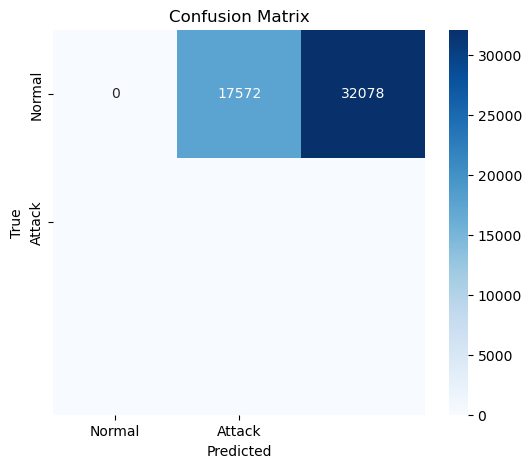

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import gym
import seaborn as sns
import matplotlib.pyplot as plt

# Load and preprocess data
df = pd.read_csv(r"C:\Users\jwajn\Desktop\Research Paper\Code\wireless_features.csv")

# Encode SSID as a categorical feature
df['ssid_encoded'] = df['ssid'].astype('category').cat.codes

# Automatically assign labels based on domain logic
df['label'] = 'normal'
df.loc[df['ssid'].isnull(), 'label'] = 'probe'
df.loc[df['frame_subtype'] == 12, 'label'] = 'deauth'

# Convert label to binary (0 = normal, 1 = attack)
df['label'] = df['label'].map({'normal': 0, 'deauth': 1, 'probe': 1})

# Extract features and labels
features = df[['frame_len', 'wlan_fc_subtype', 'signal_strength', 'channel_freq',
               'frame_type', 'frame_subtype', 'ta_is_broadcast', 'ssid_encoded']].fillna(0).values
labels = df['label'].values

# Combine features and labels into one data array
data = np.hstack((features, labels.reshape(-1, 1)))

# Initialize environment and agent
env = WirelessEnv(data)
agent = GPROAgent(state_dim=8, action_dim=2)

# Store predictions and true labels for confusion matrix
true_labels = []
predicted_labels = []

# Train loop
episodes = 10
for ep in range(episodes):
    state = env.reset()
    done = False
    total_reward = 0
    while not done:
        action = agent.act(state)
        next_state, reward, done, info = env.step(action)
        
        # Assuming the last element of the state is the true label (based on the dataset)
        true_label = state[-1]  # This assumes that the true label is the last element in the state
        true_labels.append(true_label)
        predicted_labels.append(action)  # The agent's action is the predicted label

        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

    agent.train_step()
    print(f"Episode {ep + 1}: Total Reward = {total_reward}")

# Convert lists to numpy arrays for confusion matrix
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Generate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix using seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()